In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['figure.dpi'] = 120
sns.set_theme(style='whitegrid')
print("Libraries loaded.")


Libraries loaded.


In [ ]:
\
company_df  = pd.read_csv(r'C:\Users\leetcode_problems_and_companies.csv')
leetcode_df = pd.read_csv(r'C:\Users\Leetcode.csv')

print(f"company_df  shape: {company_df.shape}")
print(f"leetcode_df shape: {leetcode_df.shape}")
display(company_df.head(3))
display(leetcode_df.head(3))


company_df  shape: (3864, 4)
leetcode_df shape: (3647, 12)


,problem_link,problem_name,company_name,num_occur
0,https://leetcode.com/problems/minimum-consecut...,Minimum Consecutive Cards to Pick Up,Google,1
1,https://leetcode.com/problems/remove-digit-fro...,Remove Digit From Number to Maximize Result,Microsoft,2
2,https://leetcode.com/problems/minimum-average-...,Minimum Average Difference,Amazon,1


,ID,Title,Difficulty,Link,Topics,Acceptance Rate (%),Premium Only,Category,Likes,Dislikes,Example Test Cases,Similar Questions
0,3641,Longest Semi-Repeating Subarray,Medium,https://leetcode.com/problems/longest-semi-rep...,NaN,71.01,True,Algorithms,2,1,NaN,[]
1,3642,Find Books with Polarized Opinions,Easy,https://leetcode.com/problems/find-books-with-...,NaN,50.77,False,Database,16,1,NaN,[]
2,3633,Earliest Finish Time for Land and Water Rides I,Easy,https://leetcode.com/problems/earliest-finish-...,"Array, Two Pointers, Binary Search, Greedy, So...",60.94,False,Algorithms,46,7,NaN,[]


In [16]:
print("company_df dtypes:")
print(company_df.dtypes)
print(f"\nUnique companies: {company_df['company_name'].nunique()}")
print("\nTop 15 companies by problem count:")
display(company_df.groupby('company_name')['problem_name'].count()
        .sort_values(ascending=False).head(15).to_frame('count'))


company_df dtypes:
problem_link    str
problem_name    str
company_name    str
num_occur       str
dtype: object

Unique companies: 187

Top 15 companies by problem count:


,count
company_name,
Amazon,592
Google,488
Facebook,371
Microsoft,363
Apple,240
Bloomberg,222
Adobe,188
Uber,129
LinkedIn,92


In [17]:
print("leetcode_df dtypes:")
print(leetcode_df.dtypes)
print("\nMissing values:")
display(leetcode_df.isnull().sum().to_frame('missing'))


leetcode_df dtypes:
ID                       int64
Title                      str
Difficulty                 str
Link                       str
Topics                     str
Acceptance Rate (%)    float64
Premium Only              bool
Category                   str
Likes                    int64
Dislikes                 int64
Example Test Cases     float64
Similar Questions          str
dtype: object

Missing values:


,missing
ID,0
Title,0
Difficulty,0
Link,0
Topics,93
Acceptance Rate (%),0
Premium Only,0
Category,0
Likes,0
Dislikes,0


In [18]:
\
# Clean company_df
company_df.columns      = company_df.columns.str.strip()
company_df['problem_link'] = company_df['problem_link'].str.strip().str.rstrip('/')
company_df['company_name'] = company_df['company_name'].str.strip().str.title()
company_df['problem_name'] = company_df['problem_name'].str.strip()
company_df['num_occur']    = pd.to_numeric(company_df['num_occur'], errors='coerce').fillna(0)
company_df.drop_duplicates(subset=['problem_link', 'company_name'], inplace=True)

# Clean leetcode_df
leetcode_df.columns   = leetcode_df.columns.str.strip()
leetcode_df['Link']   = leetcode_df['Link'].str.strip().str.rstrip('/')
leetcode_df['Difficulty']          = leetcode_df['Difficulty'].str.strip()
leetcode_df['Topics']              = leetcode_df['Topics'].fillna('Unknown')
leetcode_df['Acceptance Rate (%)'] = pd.to_numeric(leetcode_df['Acceptance Rate (%)'], errors='coerce')
leetcode_df.drop_duplicates(subset=['Link'], inplace=True)

print(f"company_df  after clean: {company_df.shape}")
print(f"leetcode_df after clean: {leetcode_df.shape}")


company_df  after clean: (3863, 4)
leetcode_df after clean: (3647, 12)


In [19]:
combined_df = pd.merge(
    company_df,
    leetcode_df,
    left_on='problem_link',
    right_on='Link',
    how='inner'
)

combined_df.drop(columns=['Link', 'problem_name'], inplace=True)

combined_df.rename(columns={
    'problem_link'        : 'url',
    'company_name'        : 'company',
    'num_occur'           : 'frequency',
    'Title'               : 'title',
    'Difficulty'          : 'difficulty',
    'Topics'              : 'topics',
    'Acceptance Rate (%)' : 'acceptance_rate',
    'Premium Only'        : 'premium',
    'Category'            : 'category',
    'Likes'               : 'likes',
    'Dislikes'            : 'dislikes',
    'ID'                  : 'problem_id'
}, inplace=True)

keep = ['problem_id','title','company','frequency','difficulty',
        'topics','acceptance_rate','premium','category','likes','dislikes','url']
combined_df = combined_df[[c for c in keep if c in combined_df.columns]]

print(f"Combined dataset shape: {combined_df.shape}")
print(f"Unique companies: {combined_df['company'].nunique()}")
display(combined_df.head(5))


Combined dataset shape: (3833, 12)
Unique companies: 187


,problem_id,title,company,frequency,difficulty,topics,acceptance_rate,premium,category,likes,dislikes,url
0,2260,Minimum Consecutive Cards to Pick Up,Google,1.0,Medium,"Array, Hash Table, Sliding Window",52.88,False,Algorithms,1062,44,https://leetcode.com/problems/minimum-consecut...
1,2259,Remove Digit From Number to Maximize Result,Microsoft,2.0,Easy,"String, Greedy, Enumeration",47.61,False,Algorithms,918,64,https://leetcode.com/problems/remove-digit-fro...
2,2256,Minimum Average Difference,Amazon,1.0,Medium,"Array, Prefix Sum",43.60,False,Algorithms,1552,180,https://leetcode.com/problems/minimum-average-...
3,2255,Count Prefixes of a Given String,Google,1.0,Easy,"Array, String",74.00,False,Algorithms,589,24,https://leetcode.com/problems/count-prefixes-o...
4,2248,Intersection of Multiple Arrays,Uber,1.0,Easy,"Array, Hash Table, Sorting, Counting",68.51,False,Algorithms,783,43,https://leetcode.com/problems/intersection-of-...


In [20]:
# Ensure frequency is numeric
combined_df['frequency'] = pd.to_numeric(combined_df['frequency'], errors='coerce').fillna(0)

# Normalized frequency per company (0-1)
combined_df['freq_score'] = combined_df.groupby('company')['frequency'].transform(
    lambda x: (x - x.min()) / (x.max() - x.min() + 1e-9)
).round(4)

# Numeric difficulty
diff_map = {'Easy': 1, 'Medium': 2, 'Hard': 3}
combined_df['difficulty_num'] = combined_df['difficulty'].map(diff_map)

# Topics as list
combined_df['topics_list'] = combined_df['topics'].apply(
    lambda x: [t.strip() for t in str(x).split(',') if t.strip() and t.strip() != 'Unknown']
)

# IR Relevance Score
combined_df['relevance_score'] = (
    combined_df['freq_score'] * 0.6 +
    (1 / combined_df['difficulty_num'].fillna(2)) * 0.4
).round(4)

print(f"frequency dtype : {combined_df['frequency'].dtype}")
print("Feature engineering complete.")
display(combined_df[['title','company','frequency','freq_score','difficulty','relevance_score']].head(8))


frequency dtype : float64
Feature engineering complete.


,title,company,frequency,freq_score,difficulty,relevance_score
0,Minimum Consecutive Cards to Pick Up,Google,1.0,0.0133,Medium,0.2080
1,Remove Digit From Number to Maximize Result,Microsoft,2.0,0.0385,Easy,0.4231
2,Minimum Average Difference,Amazon,1.0,0.0000,Medium,0.2000
3,Count Prefixes of a Given String,Google,1.0,0.0133,Easy,0.4080
4,Intersection of Multiple Arrays,Uber,1.0,0.0000,Easy,0.4000
5,Minimum Rounds to Complete All Tasks,Amazon,1.0,0.0000,Medium,0.2000
6,Calculate Digit Sum of a String,Uber,1.0,0.0000,Easy,0.4000
7,Find Closest Number to Zero,Tiger Analytics,1.0,0.0000,Easy,0.4000


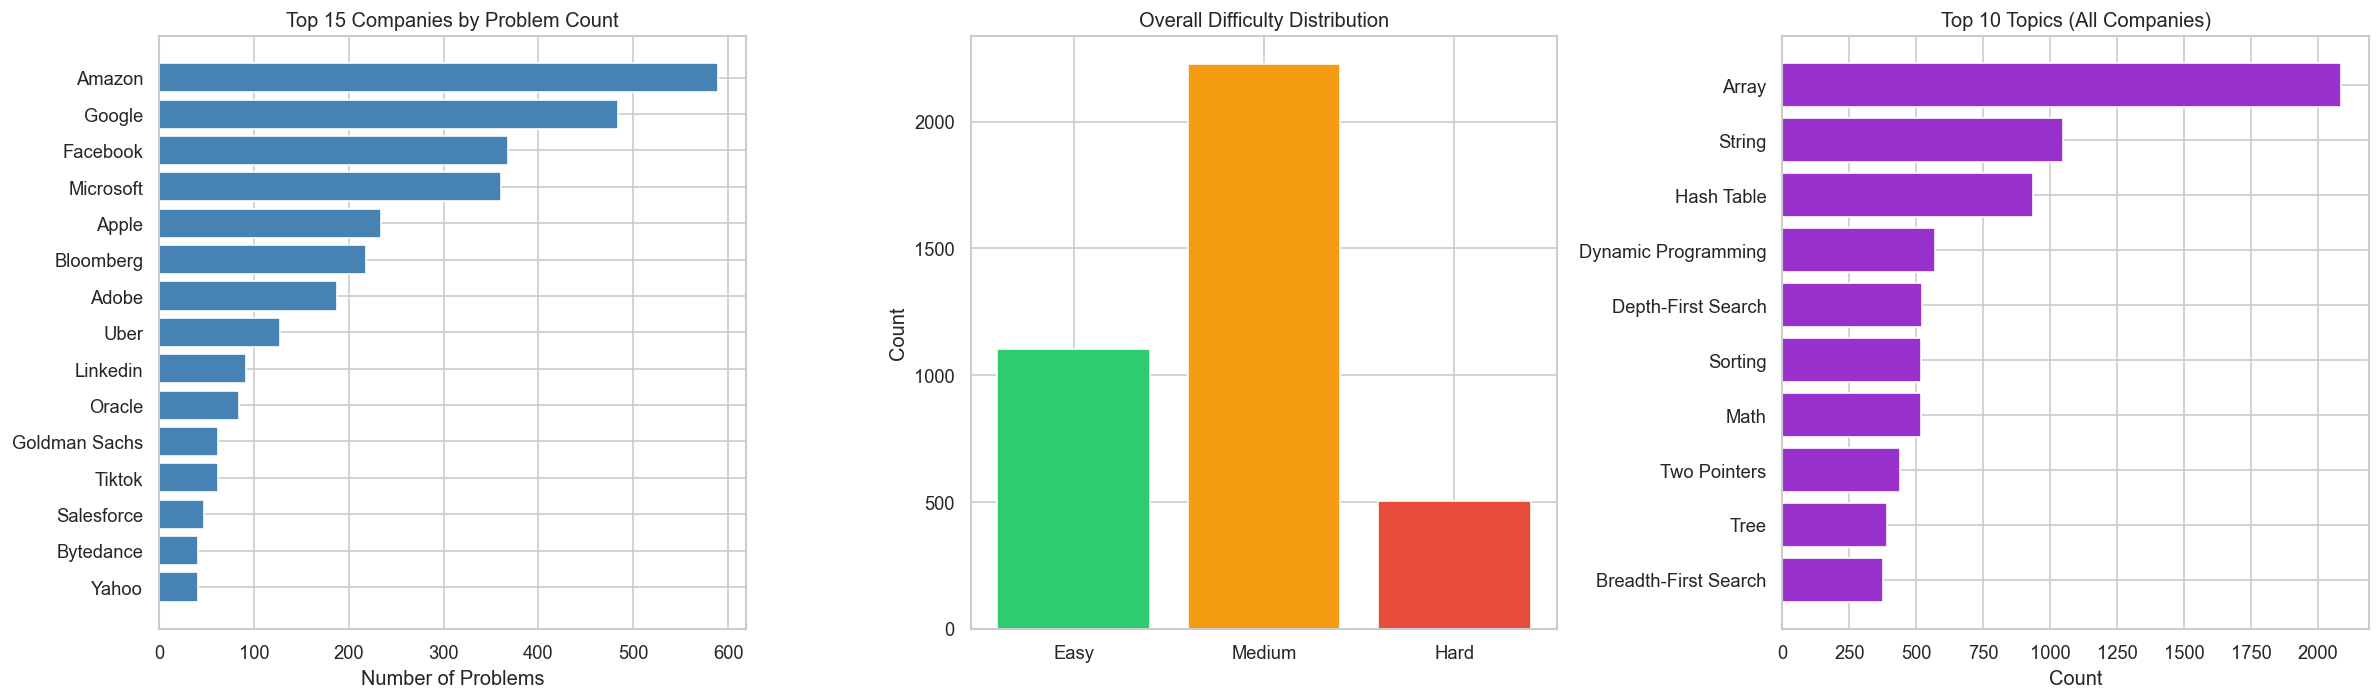

In [ ]:
\
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# 1. Top 15 companies by problem count
top_companies = combined_df['company'].value_counts().head(15)
axes[0].barh(top_companies.index[::-1], top_companies.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Companies by Problem Count')
axes[0].set_xlabel('Number of Problems')

# 2. Overall difficulty distribution
diff_counts = combined_df['difficulty'].value_counts().reindex(['Easy','Medium','Hard'], fill_value=0)
axes[1].bar(diff_counts.index, diff_counts.values, color=['#2ecc71','#f39c12','#e74c3c'])
axes[1].set_title('Overall Difficulty Distribution')
axes[1].set_ylabel('Count')

# 3. Top 10 topics across all companies
all_topics = [t for row in combined_df['topics_list'] for t in row]
topic_series = pd.Series(all_topics).value_counts().head(10)
axes[2].barh(topic_series.index[::-1], topic_series.values[::-1], color='darkorchid')
axes[2].set_title('Top 10 Topics (All Companies)')
axes[2].set_xlabel('Count')

plt.tight_layout()
plt.savefig(r'C:\Users\leetcode_overview.png', bbox_inches='tight')
plt.show()


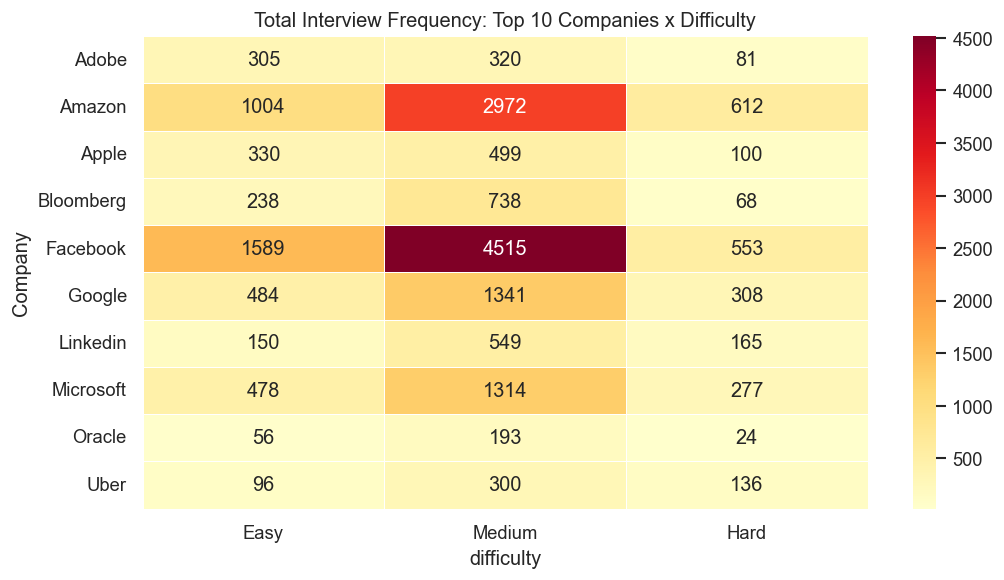

In [ ]:
\
# Heatmap: top 10 companies x difficulty (total frequency)
top10 = combined_df['company'].value_counts().head(10).index
pivot = (combined_df[combined_df['company'].isin(top10)]
         .groupby(['company','difficulty'])['frequency'].sum()
         .unstack(fill_value=0)
         .reindex(columns=['Easy','Medium','Hard'], fill_value=0))

plt.figure(figsize=(9, 5))
sns.heatmap(pivot, annot=True, fmt='g', cmap='YlOrRd', linewidths=0.5)
plt.title('Total Interview Frequency: Top 10 Companies x Difficulty')
plt.ylabel('Company')
plt.tight_layout()
plt.savefig(r'C:\Users\leetcode_heatmap.png', bbox_inches='tight')
plt.show()


In [23]:
def top_problems(company, n=10):
    df = combined_df[combined_df['company'] == company].sort_values('relevance_score', ascending=False)
    return df[['title','difficulty','topics','frequency','relevance_score']].head(n).reset_index(drop=True)

# Show top problems for top 5 companies
top5 = combined_df['company'].value_counts().head(5).index.tolist()
for co in top5:
    print(f"\n{'='*60}")
    print(f"  TOP 10 PREDICTED PROBLEMS — {co.upper()}")
    print(f"{'='*60}")
    display(top_problems(co))



  TOP 10 PREDICTED PROBLEMS — AMAZON


,title,difficulty,topics,frequency,relevance_score
0,Two Sum,Easy,"Array, Hash Table",117.0,1.0000
1,LRU Cache,Medium,"Hash Table, Linked List, Design, Doubly-Linked...",117.0,0.8000
2,Number of Islands,Medium,"Array, Depth-First Search, Breadth-First Searc...",103.0,0.7276
3,Best Time to Buy and Sell Stock,Easy,"Array, Dynamic Programming",56.0,0.6845
4,Merge Intervals,Medium,"Array, Sorting",87.0,0.6448
5,Valid Parentheses,Easy,"String, Stack",43.0,0.6173
6,First Unique Character in a String,Easy,"Hash Table, String, Queue, Counting",30.0,0.5500
7,Search Suggestions System,Medium,"Array, String, Binary Search, Trie, Sorting, H...",68.0,0.5466
8,Maximum Units on a Truck,Easy,"Array, Greedy, Sorting",29.0,0.5448
9,Roman to Integer,Easy,"Hash Table, Math, String",27.0,0.5345



  TOP 10 PREDICTED PROBLEMS — GOOGLE


,title,difficulty,topics,frequency,relevance_score
0,Find Leaves of Binary Tree,Medium,"Tree, Depth-First Search, Binary Tree",75.0,0.800
1,Evaluate Reverse Polish Notation,Medium,"Array, Math, Stack",73.0,0.784
2,Two Sum,Easy,"Array, Hash Table",44.0,0.752
3,Logger Rate Limiter,Easy,"Hash Table, Design, Data Stream",22.0,0.576
4,Happy Number,Easy,"Hash Table, Math, Two Pointers",22.0,0.576
5,First Bad Version,Easy,"Binary Search, Interactive",19.0,0.552
6,Best Time to Buy and Sell Stock,Easy,"Array, Dynamic Programming",12.0,0.496
7,Longest Common Prefix,Easy,"Array, String, Trie",12.0,0.496
8,Find Winner on a Tic Tac Toe Game,Easy,"Array, Hash Table, Matrix, Simulation",11.0,0.488
9,Snapshot Array,Medium,"Array, Hash Table, Binary Search, Design",36.0,0.488



  TOP 10 PREDICTED PROBLEMS — FACEBOOK


,title,difficulty,topics,frequency,relevance_score
0,Valid Palindrome II,Easy,"Two Pointers, String, Greedy",252.0,0.9359
1,Minimum Remove to Make Valid Parentheses,Medium,"String, Stack",282.0,0.8000
2,Range Sum of BST,Easy,"Tree, Depth-First Search, Binary Search Tree, ...",149.0,0.7160
3,Valid Word Abbreviation,Easy,"Two Pointers, String",114.0,0.6413
4,Binary Tree Vertical Order Traversal,Medium,"Hash Table, Tree, Depth-First Search, Breadth-...",188.0,0.5993
5,Valid Palindrome,Easy,"Two Pointers, String",94.0,0.5986
6,Merge Sorted Array,Easy,"Array, Two Pointers, Sorting",89.0,0.5879
7,Diameter of Binary Tree,Easy,"Tree, Depth-First Search, Binary Tree",89.0,0.5879
8,Lowest Common Ancestor of a Binary Tree,Medium,"Tree, Depth-First Search, Binary Tree",180.0,0.5822
9,"Pow(x, n)",Medium,"Math, Recursion",162.0,0.5438



  TOP 10 PREDICTED PROBLEMS — MICROSOFT


,title,difficulty,topics,frequency,relevance_score
0,Sign of the Product of an Array,Easy,"Array, Math",45.0,0.9192
1,Two Sum,Easy,"Array, Hash Table",39.0,0.8500
2,LRU Cache,Medium,"Hash Table, Linked List, Design, Doubly-Linked...",52.0,0.8000
3,Number of Islands,Medium,"Array, Depth-First Search, Breadth-First Searc...",42.0,0.6846
4,Find N Unique Integers Sum up to Zero,Easy,"Array, Math",22.0,0.6539
5,Valid Parentheses,Easy,"String, Stack",22.0,0.6539
6,Reverse Words in a String,Medium,"Two Pointers, String",34.0,0.5923
7,Best Time to Buy and Sell Stock,Easy,"Array, Dynamic Programming",14.0,0.5615
8,Missing Number,Easy,"Array, Hash Table, Math, Binary Search, Bit Ma...",13.0,0.5500
9,Merge Two Sorted Lists,Easy,"Linked List, Recursion",13.0,0.5500



  TOP 10 PREDICTED PROBLEMS — APPLE


,title,difficulty,topics,frequency,relevance_score
0,Two Sum,Easy,"Array, Hash Table",40.0,1.0000
1,Longest Common Prefix,Easy,"Array, String, Trie",14.0,0.6000
2,Roman to Integer,Easy,"Hash Table, Math, String",13.0,0.5846
3,Move Zeroes,Easy,"Array, Two Pointers",8.0,0.5077
4,Best Time to Buy and Sell Stock,Easy,"Array, Dynamic Programming",8.0,0.5077
5,Merge Sorted Array,Easy,"Array, Two Pointers, Sorting",8.0,0.5077
6,Valid Parentheses,Easy,"String, Stack",8.0,0.5077
7,Happy Number,Easy,"Hash Table, Math, Two Pointers",7.0,0.4923
8,LRU Cache,Medium,"Hash Table, Linked List, Design, Doubly-Linked...",20.0,0.4923
9,Search Insert Position,Easy,"Array, Binary Search",7.0,0.4923


In [ ]:
\
# Save final combined dataset (ALL companies)
save_df = combined_df.drop(columns=['topics_list'], errors='ignore')
save_df.to_csv(r'C:\Users\combined_leetcode_dataset.csv', index=False)

print(f"Saved: combined_leetcode_dataset.csv")
print(f"Shape: {save_df.shape}")
print(f"Unique companies: {save_df['company'].nunique()}")
print(f"Columns: {save_df.columns.tolist()}")
display(save_df.sample(5))


Saved: combined_leetcode_dataset.csv
Shape: (3833, 15)
Unique companies: 187
Columns: ['problem_id', 'title', 'company', 'frequency', 'difficulty', 'topics', 'acceptance_rate', 'premium', 'category', 'likes', 'dislikes', 'url', 'freq_score', 'difficulty_num', 'relevance_score']


,problem_id,title,company,frequency,difficulty,topics,acceptance_rate,premium,category,likes,dislikes,url,freq_score,difficulty_num,relevance_score
783,994,Rotting Oranges,Microsoft,12.0,Medium,"Array, Breadth-First Search, Matrix",57.12,False,Algorithms,14308,453,https://leetcode.com/problems/rotting-oranges,0.2308,2,0.3385
2874,124,Binary Tree Maximum Path Sum,Sprinklr,2.0,Hard,"Dynamic Programming, Tree, Depth-First Search,...",41.43,False,Algorithms,17834,772,https://leetcode.com/problems/binary-tree-maxi...,1.0000,3,0.7333
1313,617,Merge Two Binary Trees,Yahoo,3.0,Easy,"Tree, Depth-First Search, Breadth-First Search...",78.78,False,Algorithms,8975,313,https://leetcode.com/problems/merge-two-binary...,0.4000,1,0.6400
3261,56,Merge Intervals,Shopee,4.0,Medium,"Array, Sorting",49.73,False,Algorithms,23712,867,https://leetcode.com/problems/merge-intervals,0.6667,2,0.6000
2159,278,First Bad Version,Microsoft,6.0,Easy,"Binary Search, Interactive",46.14,False,Algorithms,8768,3400,https://leetcode.com/problems/first-bad-version,0.1154,1,0.4692
